**Pearson correlation coefficient**

/tmp/ipykernel_21267/1446956975.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_cmap = mpl.cm.get_cmap("magma")


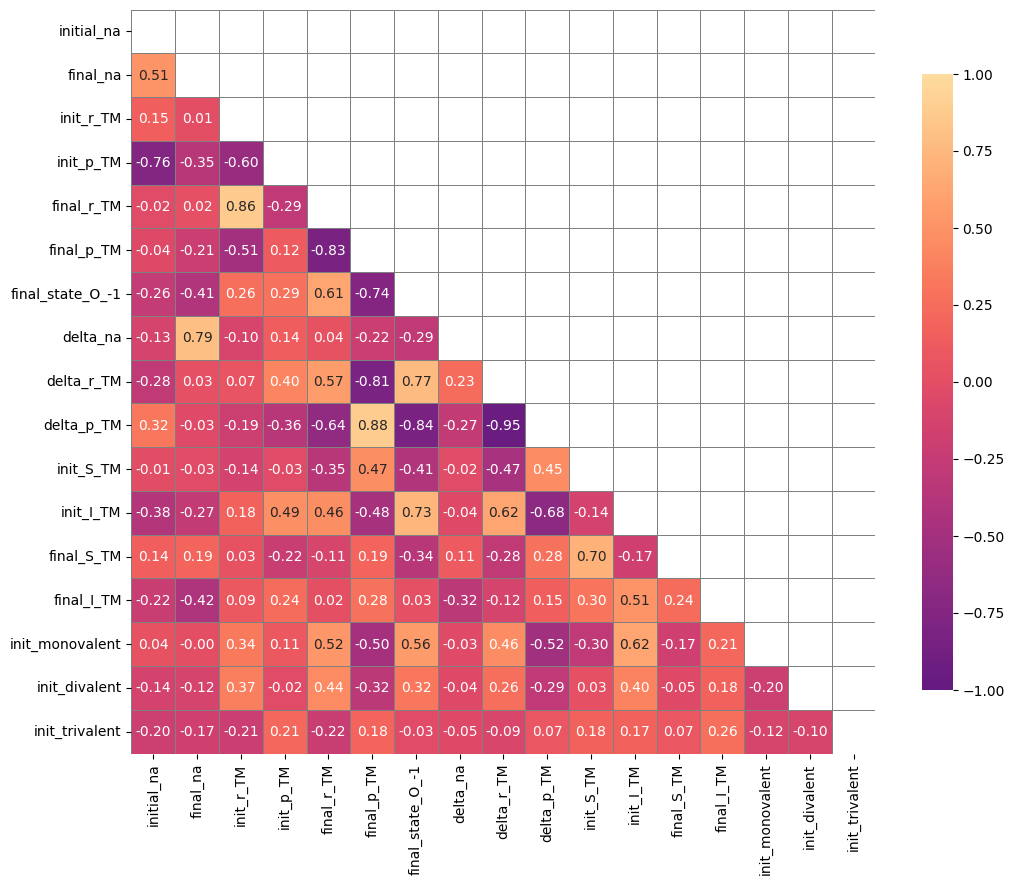

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# Load the dataset from the CSV file
raw_url = "https://raw.githubusercontent.com/LIANGTING-WU/ML_Phase_Transition/main/Phase-Transition.csv"
data = pd.read_csv(raw_url)

data['delta_na'] = data['final_na'] - data['initial_na']
data['delta_r_TM'] = data['final_r_TM'] - data['init_r_TM']
data['delta_p_TM'] = data['final_p_TM'] - data['init_p_TM']

x_features_full = [
    "initial_na", "final_na", "init_r_TM", "init_p_TM", "final_r_TM", "final_p_TM",
    "final_state_O_-1", "delta_na", "delta_r_TM", "delta_p_TM",
    "init_S_TM", "init_I_TM", "final_S_TM", "final_I_TM",
    "init_monovalent", "init_divalent", "init_trivalent"
]

# Create a new DataFrame containing only the selected features
df_features = data[x_features_full]
# Calculate the Pearson correlation matrix for the selected features
corr = df_features.corr(method='pearson')
# Create a boolean mask for the upper triangle of the matrix
# This is used to hide the redundant, mirrored half of the heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
# --- Create a modified 'magma' colormap ---
# 1. Get the original 'magma' colormap object
orig_cmap = mpl.cm.get_cmap("magma")
# 2. Create a new list of colors by sampling the original map
#    This line "slices" the colormap, taking colors from 30% to 93% of the original range
new_colors = orig_cmap(np.linspace(0.3, 0.93, 256))
# 3. Create a new, modified colormap from this list of colors
new_cmap = mpl.colors.LinearSegmentedColormap.from_list("magma_modified", new_colors)
# --- End of colormap modification ---
# Set up the matplotlib figure and define its size (width, height in inches)
plt.figure(figsize=(12, 10))
# Draw the heatmap using seaborn
ax = sns.heatmap(
    corr,
    mask=mask,           # Apply the mask to hide the upper triangle
    cmap=new_cmap,       # Use our custom-modified 'magma' colormap
    annot=True,          # Display the correlation values (annotations) in each cell
    fmt=".2f",           # Format the annotations to two decimal places
    linewidths=0.5,      # Set the width of the grid lines between cells
    cbar_kws={"shrink": 0.8}, # Make the color bar slightly smaller (80% of original height)
    square=True,         # Force the cells to be square-shaped
    linecolor='gray',    # Set the color of the grid lines
    vmin=-1,             # Set the minimum value for the color scale
    vmax=1,             # Set the maximum value for the color scale
    center=0             # Center the colormap at 0 (neutral correlation)
)

In [2]:
import io
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.decomposition import PCA
# Scikit-learn imports
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    precision_score, roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import auc  # Ensure 'auc' is imported

# ==========================================
# 0. Global Configuration
# ==========================================
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ==========================================
# 1. Data Preparation
# ==========================================
url = "https://raw.githubusercontent.com/LIANGTING-WU/ML_Phase_Transition/main/Phase-Transition.csv"
print("📥 Downloading dataset...")
s = requests.get(url).content
data_full = pd.read_csv(io.StringIO(s.decode('utf-8')))

def process_data(df):
    df_new = df.copy()
    if 'delta_na' not in df_new.columns: df_new['delta_na'] = df_new['final_na'] - df_new['initial_na']
    if 'delta_r_TM' not in df_new.columns: df_new['delta_r_TM'] = df_new['final_r_TM'] - df_new['init_r_TM']
    if 'delta_p_TM' not in df_new.columns: df_new['delta_p_TM'] = df_new['final_p_TM'] - df_new['init_p_TM']
    return df_new.fillna(0)

data_full = process_data(data_full)

features = [
    "initial_na", "final_na", "init_r_TM", "init_p_TM", "final_r_TM", "final_p_TM",
    "final_state_O_-1", "delta_na", "delta_r_TM", "delta_p_TM",
    "init_S_TM", "init_I_TM", "final_S_TM", "final_I_TM",
    "init_monovalent", "init_divalent", "init_trivalent"
]
target = "phase_change"

X = data_full[features].values
y = data_full[target].values.ravel()

# ==========================================
# 2. LOOCV Validation (Optimizing F1 & ROC Visualization)
# ==========================================
print("\n🧪 Phase 1: Executing LOOCV Validation (Tuning for F1 Score)...")

# Define the C range
cs_range = np.logspace(-2, 2, 20)

# Define the pipeline
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegressionCV(
        Cs=cs_range,
        cv=5,
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=5000,
        scoring='f1'  # Optimization target
    ))
])

loo = LeaveOneOut()

# Get probability predictions (LOOCV)
# This step performs nested CV: Outer loop (LOO) + Inner loop (5-fold for C)
y_probs_loo = cross_val_predict(
    model_pipeline, X, y, cv=loo, method="predict_proba", n_jobs=-1
)[:, 1]

# --- ROC Curve Calculation ---
fpr, tpr, thresholds = roc_curve(y, y_probs_loo)
roc_auc = auc(fpr, tpr)

# Find optimal threshold (maximize TPR - FPR)
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]
best_fpr = fpr[best_idx]
best_tpr = tpr[best_idx]

# Apply threshold to generate final class predictions
y_pred_final = (y_probs_loo >= best_threshold).astype(int)

📥 Downloading dataset...

🧪 Phase 1: Executing LOOCV Validation (Tuning for F1 Score)...


💾 Saving high-resolution plot to 'roc_curve_loocv.png'...


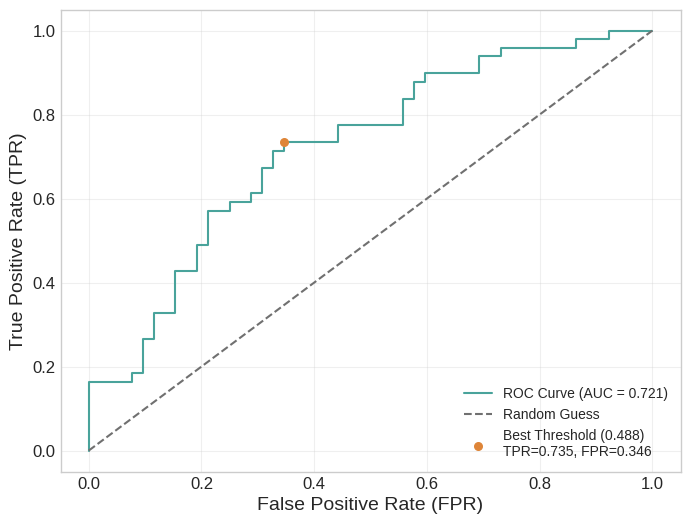


=== 🧩 Confusion Matrix (Detailed Breakdown) ===


,Predicted: No Change (0),Predicted: Phase Change (1)
Actual: No Change (0),34,18
Actual: Phase Change (1),13,36



📊 Summary Statistics:
• Total Samples: 101
• True Positives  (TP): 36  (Correctly identified Phase Change)
• False Negatives (FN): 13  (Missed Phase Change)
• True Negatives  (TN): 34  (Correctly ignored No Change)
• False Positives (FP): 18  (False Alarm)
----------------------------------------

=== 🏆 LOOCV Final Metrics (Thr=0.49) ===


,Metric,Value
0,Accuracy,0.6931
1,F1 Score,0.6990
2,Recall,0.7347
3,Precision,0.6667
4,AUC,0.7210


In [3]:
# --- Visualization: ROC Curve (Single Color, High Resolution) ---
plt.figure(figsize=(8, 6))

# 1. Plot Base Curve (Single Color)
# Changed to solid 'darkorange' for professional academic look
plt.plot(fpr, tpr, color='#49A39B', lw=1.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')

# 2. Plot Random Guess
plt.plot([0, 1], [0, 1], color='#707070', lw=1.5, linestyle='--', label='Random Guess')

# 3. Highlight the Best Threshold
plt.scatter(best_fpr, best_tpr, s=30, c='#DE8538', marker='o', zorder=10,
            label=f'Best Threshold ({best_threshold:.3f})\nTPR={best_tpr:.3f}, FPR={best_fpr:.3f}')

# Settings and Labels
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.title('Receiver Operating Characteristic (ROC) - LOOCV')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# 4. Save the figure (600 DPI)
# bbox_inches='tight' ensures no labels are cut off
filename = 'roc_curve_loocv.png'
print(f"💾 Saving high-resolution plot to '{filename}'...")
plt.savefig(filename, dpi=600, bbox_inches='tight')

plt.show()

from sklearn.metrics import confusion_matrix

# --- Detailed Statistics & Confusion Matrix ---

# 1. Calculate Confusion Matrix
# labels=[0, 1] ensures the matrix is always ordered: [TN, FP], [FN, TP]
cm = confusion_matrix(y, y_pred_final, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# 2. Create a Pandas DataFrame for the Confusion Matrix (Better Visualization)
cm_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=['Actual: No Change (0)', 'Actual: Phase Change (1)'],
    columns=['Predicted: No Change (0)', 'Predicted: Phase Change (1)']
)

print(f"\n=== 🧩 Confusion Matrix (Detailed Breakdown) ===")
try:
    # Use color highlighting if in a notebook environment
    display(cm_df.style.background_gradient(cmap='Blues', axis=None))
except:
    print(cm_df)

# 3. Text Summary for Clarity
print(f"\n📊 Summary Statistics:")
print(f"• Total Samples: {len(y)}")
print(f"• True Positives  (TP): {tp}  (Correctly identified Phase Change)")
print(f"• False Negatives (FN): {fn}  (Missed Phase Change)")
print(f"• True Negatives  (TN): {tn}  (Correctly ignored No Change)")
print(f"• False Positives (FP): {fp}  (False Alarm)")
print("-" * 40)

# 4. Standard Metrics Table
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Recall', 'Precision', 'AUC'],
    'Value': [
        accuracy_score(y, y_pred_final),
        f1_score(y, y_pred_final),
        recall_score(y, y_pred_final),
        precision_score(y, y_pred_final),
        roc_auc
    ]
})

print(f"\n=== 🏆 LOOCV Final Metrics (Thr={best_threshold:.2f}) ===")
try:
    display(metrics_df.round(4))
except NameError:
    print(metrics_df.round(4))


📊 Phase 5: Plotting Confusion Matrix Heatmap...
💾 Saving high-resolution plot to 'confusion_matrix.png'...


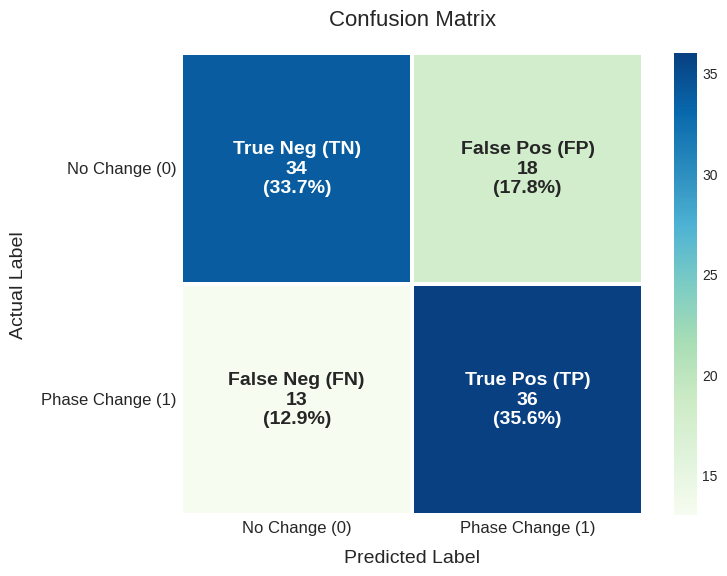

In [4]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==========================================
# 6. Visualization: Confusion Matrix Heatmap
# ==========================================
print("\n📊 Phase 5: Plotting Confusion Matrix Heatmap...")

cm = confusion_matrix(y, y_pred_final, labels=[0, 1])

group_names = ['True Neg (TN)', 'False Pos (FP)', 'False Neg (FN)', 'True Pos (TP)']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.1%}".format(value) for value in cm.flatten()/np.sum(cm)]

labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2, 2)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap='GnBu',
    cbar=True,
    xticklabels=['No Change (0)', 'Phase Change (1)'],
    yticklabels=['No Change (0)', 'Phase Change (1)'],
    annot_kws={"size": 14, "weight": "bold"},
    square=True,
    linewidths=1.5,
    linecolor='white'
)


plt.ylabel('Actual Label', fontsize=14, labelpad=10)
plt.xlabel('Predicted Label', fontsize=14, labelpad=10)
plt.title('Confusion Matrix', fontsize=16, pad=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

filename_cm = 'confusion_matrix.png'
print(f"💾 Saving high-resolution plot to '{filename_cm}'...")
plt.savefig(filename_cm, dpi=600, bbox_inches='tight')

plt.show()


 Phase 2: Training Full Model (Finding Global Best C using F1)...
Optimized Hyperparameter C (Max F1): 0.4281
Plotting Hyperparameter Tuning Curve (F1 Score)...


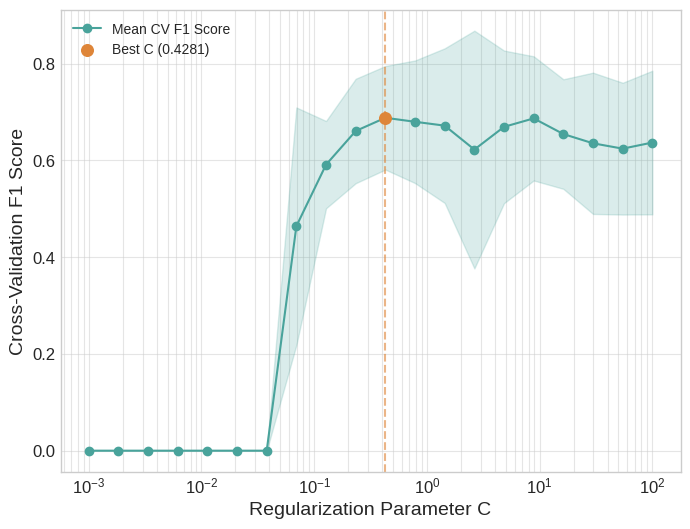

In [5]:
# ==========================================
# Full Model Analysis (SHAP & Best C by F1)
# ==========================================
print("\n Phase 2: Training Full Model (Finding Global Best C using F1)...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
cs_range = np.logspace(-3, 2, 20)

final_model_cv = LogisticRegressionCV(
    Cs=cs_range,
    cv=5,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    max_iter=5000,
    scoring='f1',
    random_state=42
)

final_model_cv.fit(X_scaled, y)
best_c = final_model_cv.C_[0]
print(f"Optimized Hyperparameter C (Max F1): {best_c:.4f}")

# --- Visualize Hyperparameter Search (F1 Score Curve) ---
print("Plotting Hyperparameter Tuning Curve (F1 Score)...")

# Retrieve scores. Since we set scoring='f1', these are now F1 scores.
cv_scores = final_model_cv.scores_[1]
mean_scores = np.mean(cv_scores, axis=0)
std_scores = np.std(cv_scores, axis=0)

plt.figure(figsize=(8, 6))
plt.semilogx(cs_range, mean_scores, label='Mean CV F1 Score', color='#49A39B', marker='o')
plt.fill_between(cs_range, mean_scores - std_scores, mean_scores + std_scores,
                 alpha=0.2, color='#49A39B')

best_score_idx = np.where(cs_range == best_c)[0][0]
best_score = mean_scores[best_score_idx]
plt.scatter(best_c, best_score, s=70, c='#DE8538', zorder=5, label=f'Best C ({best_c:.4f})')
plt.axvline(best_c, linestyle='--', color='#DE8538', alpha=0.6)

#plt.title("Hyperparameter Tuning Performance (F1 Score Optimization)") # Updated Title
plt.xlabel("Regularization Parameter C", fontsize=14)
plt.ylabel("Cross-Validation F1 Score", fontsize=14) # Updated Label
plt.legend(loc="best")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.savefig('F1_C_5_fold.png', dpi=600, bbox_inches='tight')
plt.show()

import matplotlib.pyplot as plt

Lasso selected 7 key features with C=0.4281.
💾 Saving high-resolution SHAP plot (Trimmed GnBu) to 'shap.png'...


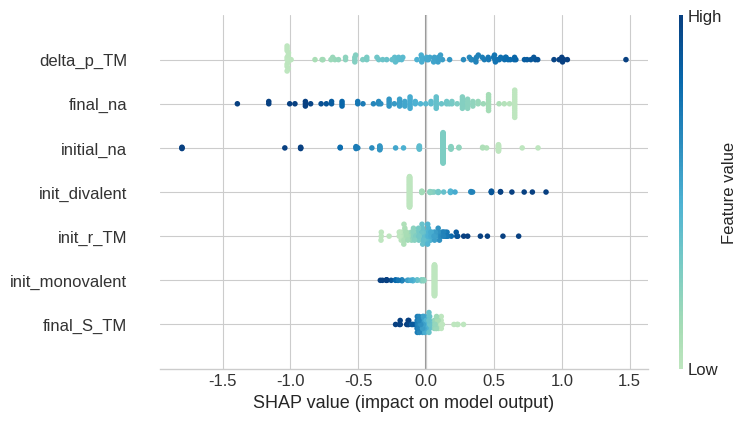

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# --- Continue with SHAP Analysis ---
coefs = final_model_cv.coef_[0]
active_mask = coefs != 0
n_active = np.sum(active_mask)
print(f"Lasso selected {n_active} key features with C={best_c:.4f}.")

if n_active > 0:
    masker = shap.maskers.Independent(data=X_scaled, max_samples=100)
    explainer = shap.LinearExplainer(final_model_cv, masker)
    shap_values_all = explainer(X_scaled)

    shap_values_clean = shap.Explanation(
        values=shap_values_all.values[:, active_mask],
        base_values=shap_values_all.base_values,
        data=X_scaled[:, active_mask],
        feature_names=np.array(features)[active_mask].tolist()
    )

    plt.figure(figsize=(10, 6))

    original_cmap = plt.get_cmap('GnBu')
    new_colors = original_cmap(np.linspace(0.3, 1.0, 256))
    gnbu_trimmed = ListedColormap(new_colors, name='GnBu_Trimmed')

    # =======================================================
    # Plotting
    # =======================================================
    shap.summary_plot(
        shap_values_clean,
        show=False,
        cmap=gnbu_trimmed  # <--- Use our custom trimmed colormap
    )

    # Font settings
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Fix Colorbar Font Size
    fig = plt.gcf()
    for ax in fig.axes:
        if ax.get_ylabel() == 'Feature value':
            ax.tick_params(labelsize=12)
            ax.set_ylabel('Feature value', fontsize=12)
            break

    # Save high-resolution image
    print("💾 Saving high-resolution SHAP plot (Trimmed GnBu) to 'shap.png'...")
    plt.savefig('shap.png', dpi=600, bbox_inches='tight')
    plt.show()


🎲 Phase 3: Bootstrap Ensemble Analysis (Stability Verification)...
   Running 100 bootstrap iterations with fixed Best C (0.4281)...
Saving high-resolution Boxplot to 'feature_stability.png'...


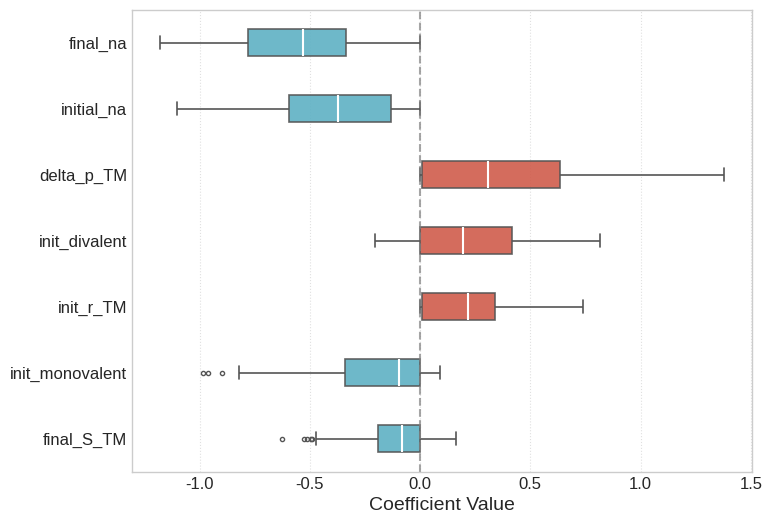

In [7]:
# ==========================================
# Bootstrap Ensemble Analysis (Stability)
# ==========================================
print("\n🎲 Phase 3: Bootstrap Ensemble Analysis (Stability Verification)...")

n_bootstraps = 100
bootstrap_probs = []
bootstrap_coefs = []

print(f"   Running {n_bootstraps} bootstrap iterations with fixed Best C ({best_c:.4f})...")

for i in range(n_bootstraps):
    X_boot, y_boot = resample(X_scaled, y, random_state=i)

    # We fix the C to the best one found by F1 optimization
    model_boot = LogisticRegressionCV(
        Cs=[best_c],
        cv=5,
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        scoring='f1', # Consistent scoring
        random_state=i
    )
    model_boot.fit(X_boot, y_boot)

    bootstrap_probs.append(model_boot.predict_proba(X_scaled)[:, 1])
    bootstrap_coefs.append(model_boot.coef_[0])

# --- Stability Plots (Refined Visuals) ---
df_coefs = pd.DataFrame(bootstrap_coefs, columns=features)
stable_features = np.array(features)[active_mask]
df_stable_coefs = df_coefs[stable_features]

order = df_stable_coefs.abs().mean().sort_values(ascending=False).index

medians = df_stable_coefs[order].median()
custom_palette = ['#E64B35' if x > 0 else '#4DBBD5' for x in medians]

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_stable_coefs[order],
    orient='h',
    palette=custom_palette,
    width=0.4,
    linewidth=1.2,
    fliersize=3,
    boxprops=dict(alpha=0.9),
    medianprops=dict(color="white", linewidth=1.5)
)


plt.axvline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
plt.xlabel("Coefficient Value", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

print("Saving high-resolution Boxplot to 'feature_stability.png'...")
plt.savefig('feature_stability.png', dpi=600, bbox_inches='tight')

plt.show()

Saving prediction confidence plot to 'confidence_analysis.png'...


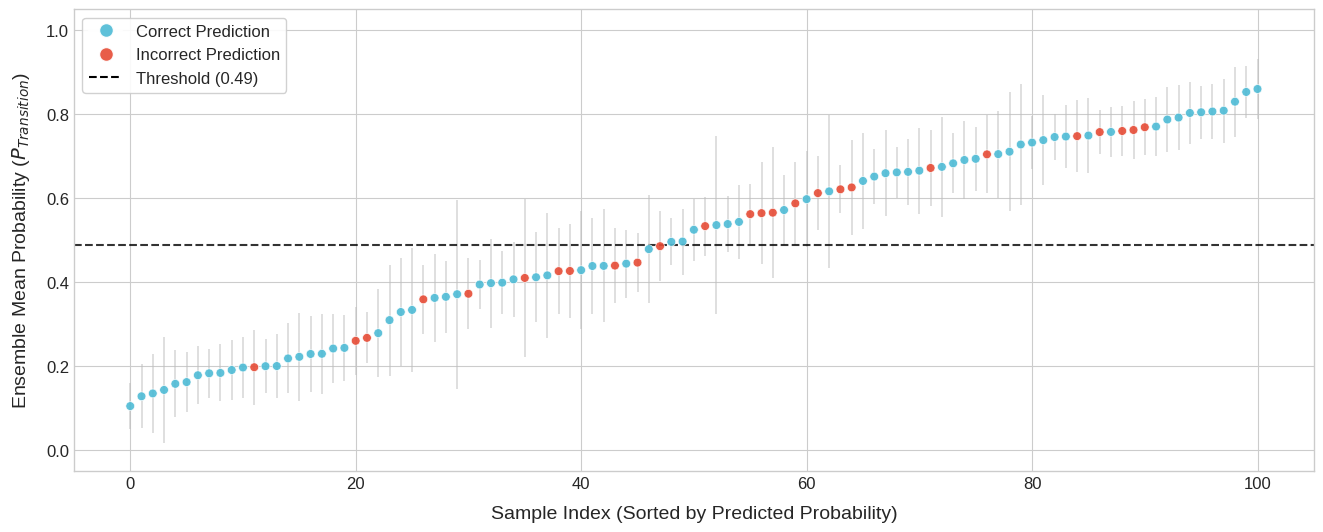

In [8]:
from matplotlib.lines import Line2D
bootstrap_probs = np.array(bootstrap_probs)
mean_probs = np.mean(bootstrap_probs, axis=0)
std_probs = np.std(bootstrap_probs, axis=0)

df_analysis = pd.DataFrame({
    'True_Label': y,
    'Ens_Mean_Prob': mean_probs,
    'Uncertainty': std_probs,
    'Prediction': (mean_probs >= best_threshold).astype(int)
})
df_analysis['Correct'] = df_analysis['True_Label'] == df_analysis['Prediction']
df_sorted = df_analysis.sort_values('Ens_Mean_Prob').reset_index(drop=True)

# --- Plotting ---
plt.figure(figsize=(16, 6))

plt.errorbar(range(len(df_sorted)), df_sorted['Ens_Mean_Prob'],
             yerr=df_sorted['Uncertainty'], fmt='none',
             ecolor='silver', elinewidth=1.2, alpha=0.6, zorder=1)
colors = ['#4DBBD5' if r.Correct else '#E64B35' for _, r in df_sorted.iterrows()]
plt.scatter(range(len(df_sorted)), df_sorted['Ens_Mean_Prob'],
            c=colors, s=40, zorder=5, edgecolors='white', linewidth=0.5, alpha=0.9)
plt.axhline(best_threshold, color='black', linestyle='--', alpha=0.8, linewidth=1.5)
plt.xlabel("Sample Index (Sorted by Predicted Probability)", fontsize=14, labelpad=10)
plt.ylabel(r"Ensemble Mean Probability ($P_{Transition}$)", fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim([-0.05, 1.05])

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4DBBD5', markersize=10, label='Correct Prediction', alpha=0.9),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E64B35', markersize=10, label='Incorrect Prediction', alpha=0.9),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label=f'Threshold ({best_threshold:.2f})')
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True, framealpha=0.9)

# Save
print("Saving prediction confidence plot to 'confidence_analysis.png'...")
plt.savefig('confidence_analysis.png', dpi=600, bbox_inches='tight')

plt.show()